## Анализ конкурентов и география

**Цель:** В этом разделе я хочу запарсить координаты уже существующих кафе с бабл ти в Москве. Так я получу список баблтишных для анализа конкурентов, а также получу тепловую карту бабл ти кафе, с помощью который я смогу понять, в каких районах не хватает бабл ти кафе.

В дальнейшем планирую замэтчить эти координаты с отзывами на эти кафе и посмотреть на то в каких районах больше бабл ти кафе с плохими отзывамм - тогда, возможно, там лучше открыться, так как конкуренты хуже работают.

**Предпосылки:**
1. За бабл ти кафе будем считать места, которые специализируются на продаже именно чайных напитков (основные признаки: тапиока, сырная пенка, молоко, китайский чай). Не учитываем заведения-рестораны, которые в первую очередь предлагают еду, но также продают бабл ти (например, корейское кафе Чико). Также не учитываем кофейни, которые специализируются на кофе и имеют несколько позиций бабл ти (например, Cofix). Хорошие примеры бабл ти кафе: Nova Bubble Tea, Met Tea.

2. Анализ конкурентнов будет проводить в центральной части Москвы (ЦАО + еще некоторые районы). В силу удобства для парсинга был взят прямоугольник с нижним левом углом в районе МГУ и правом верхнем углу в районе Сокольников.

**Источник:** В качестве источника для тепловой карты я решила взять карты 2Gis. Я сравнила эти карты с Яндекс картами и поняла, что 2Gis лучше определяет бабл ти кафе по поиску. По крайней мере, он в меньшей степени пропускает реальные баблтишные. Однако добавляет много точек, не относящихся к бабл ти кафе, как Вкусно и точка или Шоколадница.

Также есть больший минус, что с демо API-ключом 2GIS нельзя парсить неограниченное количество страниц, поэтому пришлось взять прямоугольник и разделить его на районы, для каждого из которых я по отдельности запрашивала данные.

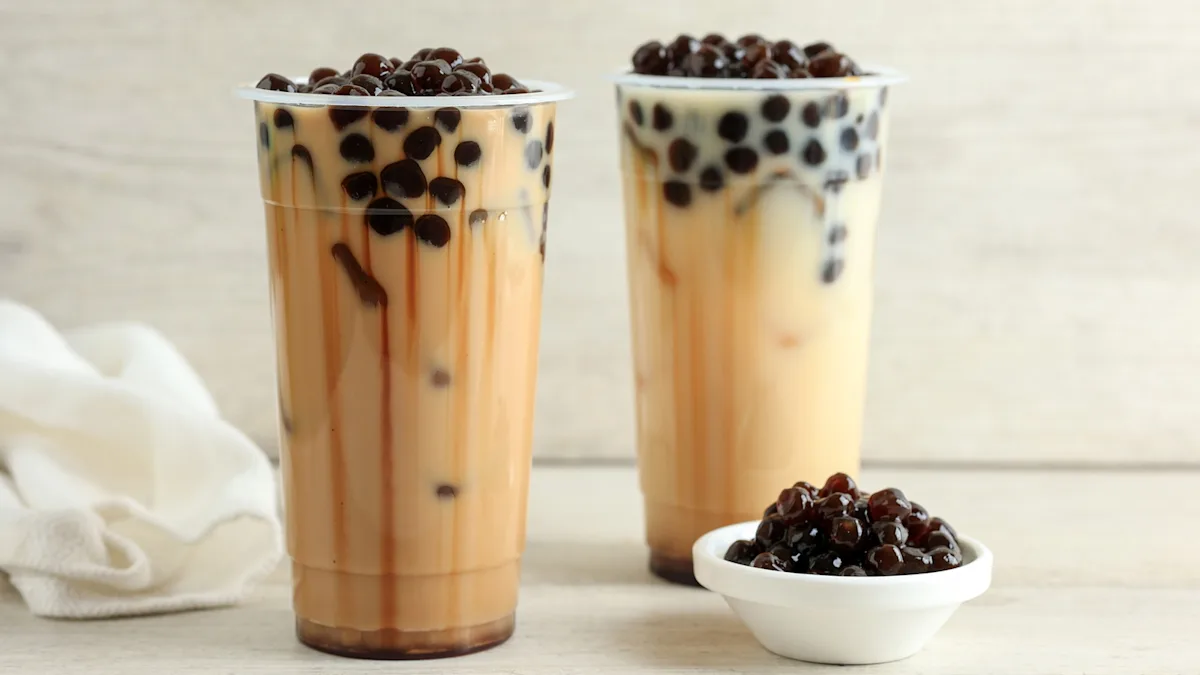


Типичный бабл ти

Так как у бесплатного API ключа 2GIS мало запросов, я решила сначала получить все точки по запросу "бабл ти", а уже потом чистить от лишних заведений.

In [2]:
import math
import time

import pandas as pd
import requests


api_key_2gis = 'f0ba0102-dea4-4d94-8f9c-3ee6dcf6a40f'

central_area = { # здесь как раз задаем прямоугльник с нижним левом углом в районе МГУ и правом верхнем углу в районе Сокольников
    'min_lon': 37.53,
    'min_lat': 55.70,
    'max_lon': 37.68,
    'max_lat': 55.80,}

PAGE_SIZE = 10
MAX_PAGES = 5
RADIUS_M = 1200
GRID_STEP_M = 1700
REQUEST_PAUSE = 0.15

In [3]:
def make_grid(bbox: dict, step_m: int) -> list[str]:
    points = []

    lat = bbox['min_lat']
    lat_step = step_m / 111_320

    while lat <= bbox['max_lat']:
        lon = bbox['min_lon']
        lon_step = step_m / (111_320 * math.cos(math.radians(lat)))

        while lon <= bbox['max_lon']:
            points.append(f'{lon:.6f},{lat:.6f}')
            lon += lon_step

        lat += lat_step

    return points

In [4]:
def load_2gis_items(
    params: dict,
    page_size: int = PAGE_SIZE,
    max_pages: int | None = MAX_PAGES,
) -> list[dict]:
    url = 'https://catalog.api.2gis.com/3.0/items'

    response = requests.get(url, params={**params, 'page': 1, 'page_size': page_size})
    response.raise_for_status()

    data = response.json()

    result = data.get('result', {})
    total = result.get('total', 0)
    items = result.get('items', [])

    pages_count = math.ceil(total / page_size) # считаем, сколько страниц нужно загрузить

    if max_pages is not None:
        pages_count = min(pages_count, max_pages)

    for page in range(2, pages_count + 1):
        response = requests.get(
            url,
            params={**params, 'page': page, 'page_size': page_size},
            timeout=20,
        )
        response.raise_for_status()

        data = response.json()
        items.extend(data.get('result', {}).get('items', []))
        time.sleep(REQUEST_PAUSE)

    return items


def collect_2gis_items_by_grid( # вот эта уже запускает прошлую функцию для каждой точки
    query: str,
    points: list[str],
    api_key: str,
    radius_m: int,
) -> list[dict]:
    items = []

    for point in points:
        params = {
            'q': 'бабл ти',
            'type': 'branch',
            'fields': 'items.point',
            'point': point,
            'radius': radius_m,
            'key': api_key,
        }

        items.extend(load_2gis_items(params))
        time.sleep(REQUEST_PAUSE)

    return items

In [5]:
def make_dirty_places_df(items: list[dict]) -> pd.DataFrame: # тут мы просто из json делаем датасет
    if not items:
        return pd.DataFrame(columns=['id', 'name', 'full_name', 'address', 'lat', 'lon'])

    df = pd.json_normalize(items)

    columns = {
        'id': 'id',
        'name': 'name',
        'full_name': 'full_name',
        'address_name': 'address',
        'point.lat': 'lat',
        'point.lon': 'lon',
    }

    existing_columns = {
        old: new
        for old, new in columns.items()
        if old in df.columns
    }

    df = df.rename(columns=existing_columns)

    result_columns = [
        column
        for column in columns.values()
        if column in df.columns
    ]

    df = df[result_columns].copy()

    if 'id' in df.columns:
        df = df.drop_duplicates(subset=['id'])

    return df.reset_index(drop=True)

In [23]:
# эту ячейку я закомментила, потому что уже собрала данные и случайно ее перезапустила, при этом не хочу тратить api запросы, а таблицу я уже сохранила

# points = make_grid(central_area, GRID_STEP_M) # тут уже все делаем что нам нужно

# raw_items = collect_2gis_items_by_grid(
#     query='бабл ти',
#     points=points,
#     api_key=api_key_2gis,
#     radius_m=RADIUS_M,
# )

# dirty_places_df = make_dirty_places_df(raw_items)

# dirty_places_df

In [24]:
from google.colab import files

dirty_places_df.to_csv("dirty_places.csv", index=False, encoding="utf-8-sig")
files.download("dirty_places.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Тут я поработала с таблицей вручную, выявила некоторые закономерности, ключевые слова, по которым можно определить бабл ти кафе это или нет (тут можно полагаться на мою экспертность в области бабл ти)

In [28]:
positive_pattern = r"чай|tea|бабл|bubble|boba"
negative_pattern = r"кухня|кухни|стритфуд|стритфуда|фастфуд|фастфуда|пекарня|кофейня|кофе|coffee|coffeeshop|быстрое питание|быстрого питания|мороженое|бистро|кондитерская|суши"

name = dirty_places_df["name"].fillna("").str.lower()

has_positive = name.str.contains(positive_pattern, regex=True)
has_negative = name.str.contains(negative_pattern, regex=True)

clean_places_df = dirty_places_df[
    has_positive | (~has_positive & ~has_negative)
].copy()

clean_places_df = clean_places_df.reset_index(drop=True)

clean_places_df.head(15)

,id,name,full_name,address,lat,lon
0,70000001085801600,MojiTea bubble tea,NaN,"Ломоносовский проспект, 25 к5",55.692313,37.531752
1,70000001105863611,"Pims, магазин безалкогольных напитков",NaN,"Мичуринский проспект, 13а ст1",55.698676,37.513221
2,70000001077409967,"Davs Tea, безалкогольный бар",NaN,"площадь Джавахарлала Неру, 1",55.693451,37.534068
3,70000001095287732,"MosTea&Мифэнь, кофейня",NaN,"Вернадского проспект, 11",55.689362,37.530221
4,70000001105863722,Bobarista,NaN,"Мичуринский проспект, 13а ст1",55.698676,37.513221
5,70000001097876121,"Good Tea, чайное кафе",NaN,"Ленинский проспект, 37а",55.709293,37.587828
6,70000001091814646,"Met Tea, китайская чайная",NaN,"улица Вавилова, 3",55.707180,37.590320
7,70000001061501735,"Baobei, чайная",NaN,"улица Вавилова, 3",55.706018,37.593959
8,70000001100787787,Киоск безалкогольных напитков,NaN,"улица Вавилова, 3",55.706414,37.594250
9,70000001109738050,"Mani, бабл-ти бар",NaN,"Большая Тульская улица, 13",55.708307,37.622049


Вследствие анализа таблицы сверху я поняла, что в ней большинство заведений действительноя являются бабл ти кафе, но также есть много заведений без каких-либо характеристик, которые с большой вероятностью не подходят нам. Посмотрим на такие заведения. Проанализировав их и вручную добавив в регулярное выражение название нужных нам баблтишных, получили что эти остатки состоят из заведений, которые довольно очевидно не относятся к бабл ти кафе.

In [35]:
positive_pattern = r"чай|tea|бабл|bubble|boba|pims|чая|youzhi cha|hicha|won Cha|mani|yummo|yong cha|micha|boosty|bao bei"

name = clean_places_df["name"].fillna("").str.lower()
has_positive = name.str.contains(positive_pattern, regex=True)

tea_places_df = clean_places_df[has_positive].copy().reset_index(drop=True)
not_tea_places_df = clean_places_df[~has_positive].copy().reset_index(drop=True)
not_tea_places_df.head(10)

,id,name,full_name,address,lat,lon
0,70000001100787787,Киоск безалкогольных напитков,NaN,"улица Вавилова, 3",55.706414,37.594250
1,70000001110654821,Bao Bao,NaN,"Большая Тульская улица, 13",55.709226,37.622311
2,70000001099177992,"Тропикана, бар",NaN,"Андропова проспект, 1",55.695761,37.676737
3,70000001087528021,Tsardog,NaN,"Андропова проспект, 1",55.695769,37.677097
4,70000001098574894,Хот-дог и бургер,NaN,"Андропова проспект, 8",55.696247,37.664816
5,70000001021461937,"Bo cafe, вьетнамское кафе",NaN,"Мытная улица, 74",55.711964,37.620234
6,70000001064985861,"Fu Yang, точка безалкогольных напитков",NaN,"улица Ленинская Слобода, 26",55.709300,37.653181
7,70000001103340973,Gо ко мне,NaN,"Восточная улица, 13",55.712244,37.658880
8,70000001109996083,Space bar,NaN,"7-я Кожуховская улица, 9",55.710179,37.675068
9,70000001066640905,"Gabo, кафе",NaN,"Погодинская улица, 8",55.733444,37.569159


Итоговый датасет, с которым мы будем работать - tea_places_df.

Попробуем построить тепловую карт баблтишек.

In [38]:
import folium
from folium.plugins import HeatMap

map_df = tea_places_df.dropna(subset=["lat", "lon"]).copy()

moscow_map = folium.Map(
    location=[55.751244, 37.618423],
    zoom_start=11
)

heat_data = map_df[["lat", "lon"]].values.tolist()

HeatMap(
    heat_data,
    radius=18,
    blur=14,
    min_opacity=0.35
).add_to(moscow_map)

from IPython.display import display

display(moscow_map)